In [ ]:
#!pip install tensorflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import scipy.io
from scipy.io import loadmat
from scipy import signal, ndimage

In [2]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'

### Edge detection with convolution

In [2]:
x = np.array([[4,2,9,4,7,1],
             [3,1,5,3,2,5],
             [8,7,1,2,6,2],
             [6,3,0,1,8,1],
             [1,4,1,5,7,8],
             [2,0,9,1,3,9]])
h = np.array([[1,0,-1],
             [1,0,-1],
             [1,0,-1]])

In [3]:
h = h[::-1,::-1]

In [4]:
signal.convolve2d(x,h,mode='valid')

array([[  0,   1,   0,   1],
       [ 11,   5, -10,  -2],
       [ 13,   6, -19,  -3],
       [ -1,   0,  -8, -11]])

In [5]:
# small image data with a vertical edge
x1 = np.array([[20,20,20,0,0,0],
             [20,20,20,0,0,0],
             [20,20,20,0,0,0],
             [20,20,20,0,0,0],
             [20,20,20,0,0,0],
             [20,20,20,0,0,0]])

In [6]:
signal.convolve2d(x1,h,mode='valid')

array([[ 0, 60, 60,  0],
       [ 0, 60, 60,  0],
       [ 0, 60, 60,  0],
       [ 0, 60, 60,  0]])

#### Example 1 : vertical edge detection

In [10]:
#!pip install pooch

**Note :** You may need to restart kernel after install pooch.

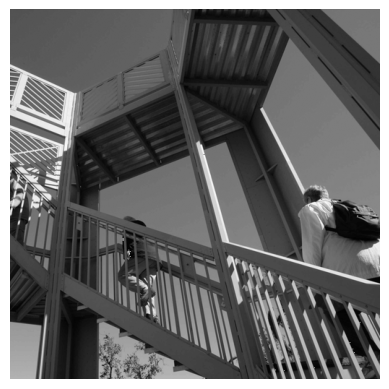

In [7]:
ascent_img = scipy.datasets.ascent()
plt.imshow(ascent_img, cmap='gray')
plt.axis('off')
plt.show()


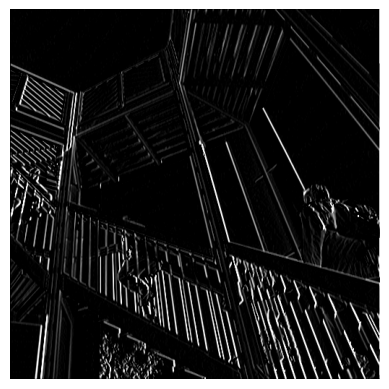

In [8]:
ascent_vertedge = signal.convolve2d(ascent_img,h,mode='same')
plt.imshow(ascent_vertedge, cmap='gray',vmin=0,vmax=255)
plt.axis('off')
plt.show()

#### Example 2 : The Street View House Number (SVHN) 

http://ufldl.stanford.edu/housenumbers/ 

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping, LearningRateScheduler 
from tensorflow.keras.optimizers import Adam

In [10]:
train = loadmat('data/train_32x32.mat')
test = loadmat('data/test_32x32.mat')
train_images_rgb, train_labels = train['X'],train['y']
test_images_rgb, test_labels = test['X'],test['y']
train_images_rgb = np.moveaxis(train_images_rgb, 3,0) # permute axis so that number of samples come first
test_images_rgb = np.moveaxis(test_images_rgb, 3,0)
N = train_images_rgb.shape[0]
train_labels = np.where(train_labels==10,0,train_labels)
test_labels = np.where(test_labels==10,0,test_labels)
train_images = np.mean(train_images_rgb,axis=-1,keepdims=True)/255.
test_images = np.mean(test_images_rgb,axis=-1,keepdims=True)/255.

In [11]:
# DNN model
model_dnn = Sequential([
    Flatten(input_shape=(32,32,1)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dense(128, activation = 'relu'),
    BatchNormalization(),
    Dense(10, activation = 'softmax')    
])

/opt/miniconda3/envs/mlpi/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model_dnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,458 (783.04 KB)

 Trainable params: 199,434 (779.04 KB)

 Non-trainable params: 1,024 (4.00 KB)

In [13]:
model_dnn.compile(optimizer=Adam(learning_rate=0.001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [14]:
def scheduler(epoch, lr):
    return lr * (1/(1+epoch))
lr_scheduler = LearningRateScheduler(scheduler, verbose=1)
early_stopping = EarlyStopping(patience=3, monitor='val_accuracy', mode='max')

In [15]:
history_dnn=model_dnn.fit(train_images, train_labels, epochs=30, batch_size=256, validation_split = 0.15,
                  callbacks=[lr_scheduler,early_stopping])


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5964 - loss: 1.2725 - val_accuracy: 0.4579 - val_loss: 1.6079 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7543 - loss: 0.8034 - val_accuracy: 0.6505 - val_loss: 1.0973 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00016666667458290854.
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.6796 - val_accuracy: 0.7224 - val_loss: 0.8775 - learning_rate: 1.6667e-04

Epoch 4: LearningRateScheduler setting learning rate to 4.166666985838674e-05.
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8096 - loss: 0.6328 - val_accuracy: 0.7832 - val_loss: 0.7029 - learning_rate: 4.1667e-05

Epoch 5: LearningRateScheduler setting learning rate to 8.

In [16]:
# use history.history in agrument 
def plot_acc_loss(history):
    acc=history['accuracy']
    val_acc=history['val_accuracy']
    loss=history['loss']
    val_loss=history['val_loss']
    epochs=range(len(acc)) # Get number of epochs

    acc_txt = str(round(acc[len(acc)-1]*100,2))
    val_acc_txt = str(round(val_acc[len(val_acc)-1]*100,2))

    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.plot(epochs, acc,'r',epochs,val_acc,'b')
    ax1.set_title('Training and validation accuracy')
    ax1.legend(["Training acc = "+acc_txt+" %","Validation acc = "+val_acc_txt+" %"])

    loss_txt = str(round(loss[len(loss)-1],2))
    val_loss_txt = str(round(val_loss[len(val_loss)-1],2))

    ax2.plot(epochs, loss, 'r',epochs, val_loss, 'b')
    ax2.legend(["Training loss = "+loss_txt,"Validation loss = "+val_loss_txt])
    ax2.set_title('Training and validation loss');


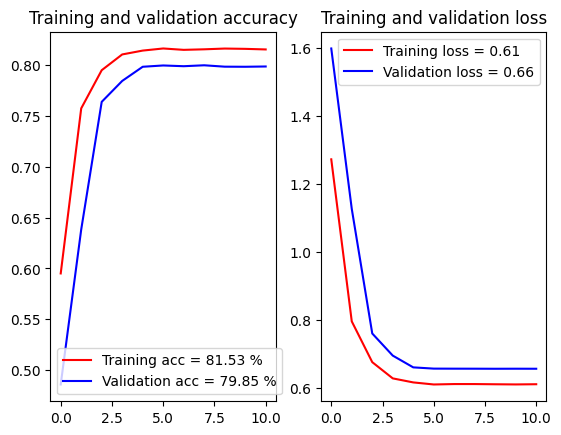

In [19]:
plot_acc_loss(history_dnn.history)

In [17]:
# CNN model
model_cnn = Sequential([
    Conv2D(16, (3,3), activation='relu',input_shape=(32,32,1)),
    MaxPooling2D(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),    
    BatchNormalization(),
    Dropout(0.5),
    BatchNormalization(),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(64, activation = 'relu'),  
    Dense(10, activation = 'softmax')    
])
model_cnn.summary()

/opt/miniconda3/envs/mlpi/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,658 (326.79 KB)

 Trainable params: 83,530 (326.29 KB)

 Non-trainable params: 128 (512.00 B)

In [18]:
model_cnn.compile(optimizer=Adam(learning_rate=0.001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [19]:
history_cnn=model_cnn.fit(train_images, train_labels, epochs=30, batch_size=256, validation_split = 0.15,
                  callbacks=[lr_scheduler,early_stopping])


Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5957 - loss: 1.2249 - val_accuracy: 0.4037 - val_loss: 1.8335 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0005000000237487257.
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8075 - loss: 0.6273 - val_accuracy: 0.8162 - val_loss: 0.9351 - learning_rate: 5.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00016666667458290854.
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8282 - loss: 0.5584 - val_accuracy: 0.8584 - val_loss: 0.5003 - learning_rate: 1.6667e-04

Epoch 4: LearningRateScheduler setting learning rate to 4.166666985838674e-05.
Epoch 4/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.8354 - loss: 0.5378 - val_accuracy: 0.8657 - val_loss: 0.4582 - learning_rate: 4.1667e-05

Epoch 5: LearningRateScheduler setting learning rate t

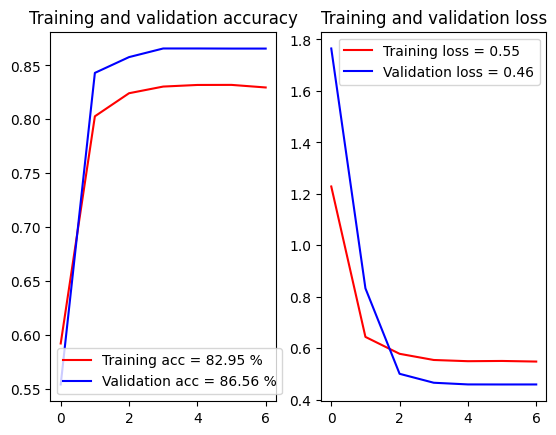

In [23]:
plot_acc_loss(history_cnn.history)

#### Comparison between DNN and CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


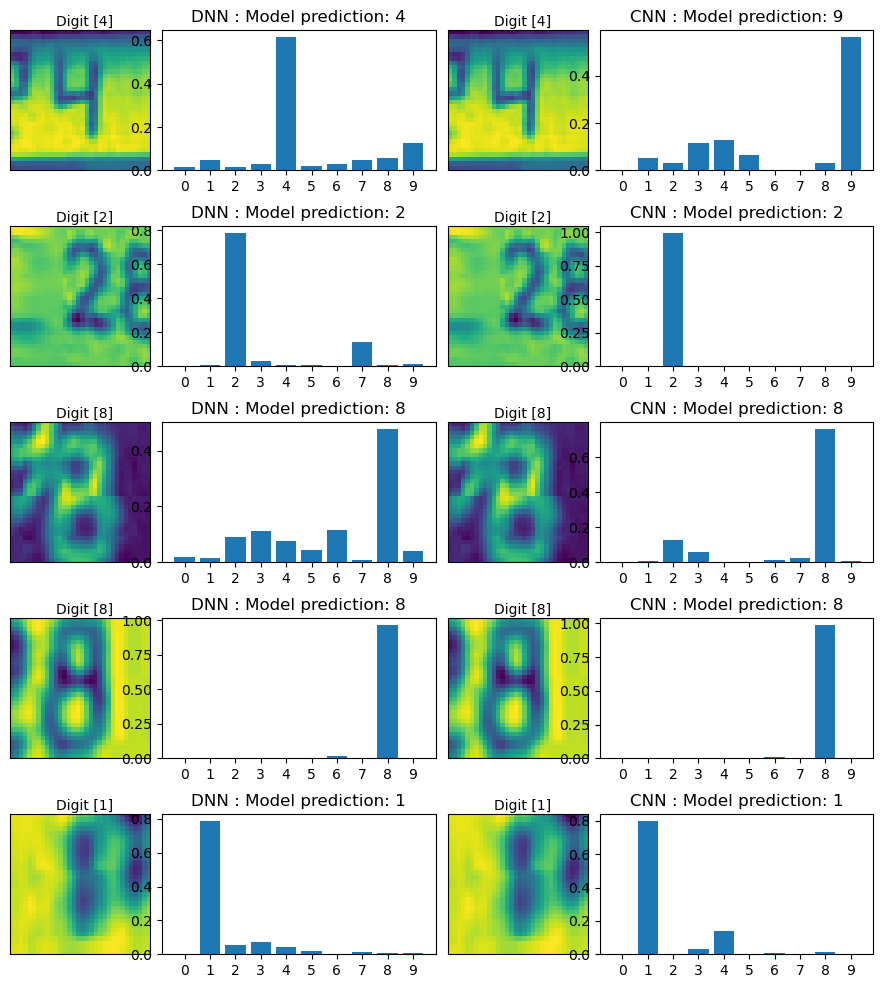

In [20]:
num_test_images = test_images.shape[0]
random_inx = np.random.choice(num_test_images, 5)
random_test_images = test_images[random_inx, ...]
random_test_labels = test_labels[random_inx, ...]


DNN_predictions = model_dnn.predict(random_test_images) 
CNN_predictions = model_cnn.predict(random_test_images)

#do the plots
fig, axes = plt.subplots(5, 4, figsize=(12, 12))
fig.subplots_adjust(hspace=0.4, wspace=-0.2)

for i, (prediction, image, label) in enumerate(zip(DNN_predictions, random_test_images, random_test_labels)):
    axes[i, 0].imshow(np.squeeze(image))
    axes[i, 0].get_xaxis().set_visible(False)
    axes[i, 0].get_yaxis().set_visible(False)
    axes[i, 0].text(10., -1.5, f'Digit {label}')
    axes[i, 1].bar(np.arange(len(prediction)), prediction)
    axes[i, 1].set_xticks(np.arange(len(prediction)))
    axes[i, 1].set_title(f"DNN : Model prediction: {np.argmax(prediction)}")

for i, (prediction, image, label) in enumerate(zip(CNN_predictions, random_test_images, random_test_labels)):
    axes[i, 2].imshow(np.squeeze(image))
    axes[i, 2].get_xaxis().set_visible(False)
    axes[i, 2].get_yaxis().set_visible(False)
    axes[i, 2].text(10., -1.5, f'Digit {label}')
    axes[i, 3].bar(np.arange(len(prediction)), prediction)
    axes[i, 3].set_xticks(np.arange(len(prediction)))
    axes[i, 3].set_title(f"CNN : Model prediction: {np.argmax(prediction)}")    

plt.show()

#### Cat v.s. Dog classification example

In [2]:
!wget --no-check-certificate \
  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
  -O /tmp/cats_and_dogs_filtered.zip

--2025-10-30 09:14:08--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 2404:6800:4016:80f::201b, 2404:6800:4016:80e::201b, 2404:6800:4016:809::201b, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|2404:6800:4016:80f::201b|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 68606236 (65M) [application/zip]
Saving to: ‘/tmp/cats_and_dogs_filtered.zip’

/tmp/cats_and_dogs_ 100%[===================>]  65.43M  10.0MB/s    in 6.9s    

2025-10-30 09:14:15 (9.42 MB/s) - ‘/tmp/cats_and_dogs_filtered.zip’ saved [68606236/68606236]



In [2]:
import os
import zipfile

local_zip = '/tmp/cats_and_dogs_filtered.zip'

zip_ref = zipfile.ZipFile(local_zip, 'r')

zip_ref.extractall('/tmp')
zip_ref.close()

In [3]:
base_dir = '/tmp/cats_and_dogs_filtered'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

# Directory with our training cat/dog pictures
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

# Directory with our validation cat/dog pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

In [4]:
train_cat_fnames = os.listdir( train_cats_dir )
train_dog_fnames = os.listdir( train_dogs_dir )

print(train_cat_fnames[:10])
print(train_dog_fnames[:10])

['cat.952.jpg', 'cat.946.jpg', 'cat.6.jpg', 'cat.749.jpg', 'cat.991.jpg', 'cat.985.jpg', 'cat.775.jpg', 'cat.761.jpg', 'cat.588.jpg', 'cat.239.jpg']
['dog.775.jpg', 'dog.761.jpg', 'dog.991.jpg', 'dog.749.jpg', 'dog.985.jpg', 'dog.952.jpg', 'dog.946.jpg', 'dog.211.jpg', 'dog.577.jpg', 'dog.563.jpg']


In [5]:
print('training examples (cat) :', len(os.listdir(      train_cats_dir ) ))
print('training examples (dog) :', len(os.listdir(      train_dogs_dir ) ))

print('test examples (cat) :', len(os.listdir( validation_cats_dir ) ))
print('test examples (dog) :', len(os.listdir( validation_dogs_dir ) ))

training examples (cat) : 1000
training examples (dog) : 1000
test examples (cat) : 500
test examples (dog) : 500


In [6]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

nrows = 4
ncols = 4
pic_index = 0 

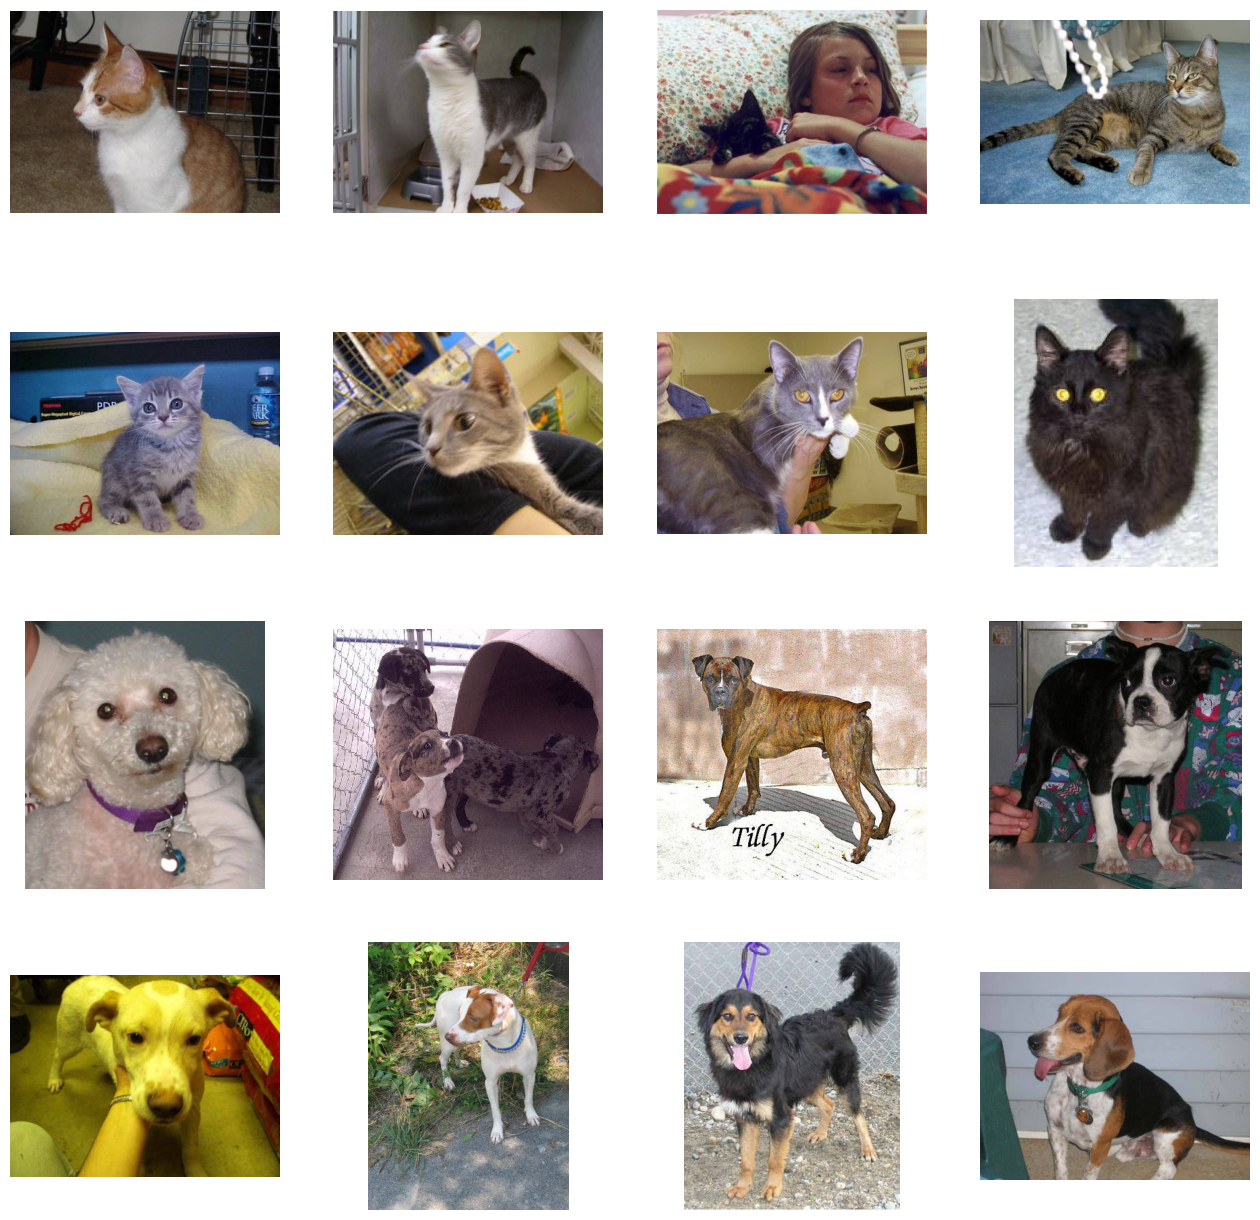

In [7]:
fig = plt.gcf()
fig.set_size_inches(ncols*4, nrows*4)
pic_index+=8
next_cat_pix = [os.path.join(train_cats_dir, fname) 
                for fname in train_cat_fnames[ pic_index-8:pic_index] 
               ]

next_dog_pix = [os.path.join(train_dogs_dir, fname) 
                for fname in train_dog_fnames[ pic_index-8:pic_index]
               ]
for i, img_path in enumerate(next_cat_pix+next_dog_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off') 
    img = mpimg.imread(img_path)
    plt.imshow(img)
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten 
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

In [9]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2), 
    Conv2D(64, (3,3), activation='relu'), 
    MaxPooling2D(2,2),
    Flatten(), 
    Dense(512, activation='relu'), 
    Dense(1, activation='sigmoid')  
])

/opt/miniconda3/envs/mlpi/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics = ['accuracy'])

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator( rescale = 1.0/255. )
test_datagen  = ImageDataGenerator( rescale = 1.0/255. )
train_generator = train_datagen.flow_from_directory(train_dir,batch_size=20,class_mode='binary',target_size=(150, 150))     
validation_generator =  test_datagen.flow_from_directory(validation_dir,batch_size=20,class_mode  = 'binary',target_size = (150, 150))

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [13]:
history = model.fit(train_generator,validation_data=validation_generator,steps_per_epoch=100,epochs=15,validation_steps=50,verbose=2)

Epoch 1/15
100/100 - 9s - 92ms/step - accuracy: 0.5400 - loss: 0.6939 - val_accuracy: 0.4920 - val_loss: 0.6831
Epoch 2/15
100/100 - 8s - 82ms/step - accuracy: 0.6365 - loss: 0.6317 - val_accuracy: 0.6550 - val_loss: 0.6150
Epoch 3/15
100/100 - 8s - 83ms/step - accuracy: 0.6885 - loss: 0.5813 - val_accuracy: 0.6950 - val_loss: 0.5827
Epoch 4/15
100/100 - 8s - 84ms/step - accuracy: 0.7120 - loss: 0.5392 - val_accuracy: 0.6980 - val_loss: 0.5776
Epoch 5/15
100/100 - 9s - 87ms/step - accuracy: 0.7420 - loss: 0.5026 - val_accuracy: 0.7280 - val_loss: 0.5495
Epoch 6/15
100/100 - 8s - 84ms/step - accuracy: 0.7940 - loss: 0.4406 - val_accuracy: 0.6790 - val_loss: 0.6575
Epoch 7/15
100/100 - 9s - 86ms/step - accuracy: 0.8350 - loss: 0.3666 - val_accuracy: 0.6960 - val_loss: 0.6233
Epoch 8/15
100/100 - 9s - 88ms/step - accuracy: 0.8705 - loss: 0.3157 - val_accuracy: 0.7250 - val_loss: 0.6871
Epoch 9/15
100/100 - 9s - 86ms/step - accuracy: 0.9090 - loss: 0.2324 - val_accuracy: 0.7150 - val_loss:

In [14]:
# use history.history in agrument 
def plot_acc_loss(history):
    acc=history['accuracy']
    val_acc=history['val_accuracy']
    loss=history['loss']
    val_loss=history['val_loss']
    epochs=range(len(acc)) # Get number of epochs
    acc_txt = str(round(acc[len(acc)-1]*100,2))
    val_acc_txt = str(round(val_acc[len(val_acc)-1]*100,2))
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.plot(epochs, acc,'r',epochs,val_acc,'b')
    ax1.set_title('Training and validation accuracy')
    ax1.legend(["Training acc = "+acc_txt+" %","Validation acc = "+val_acc_txt+" %"])
    loss_txt = str(round(loss[len(loss)-1],2))
    val_loss_txt = str(round(val_loss[len(val_loss)-1],2))
    ax2.plot(epochs, loss, 'r',epochs, val_loss, 'b')
    ax2.legend(["Training loss = "+loss_txt,"Validation loss = "+val_loss_txt])
    ax2.set_title('Training and validation loss');

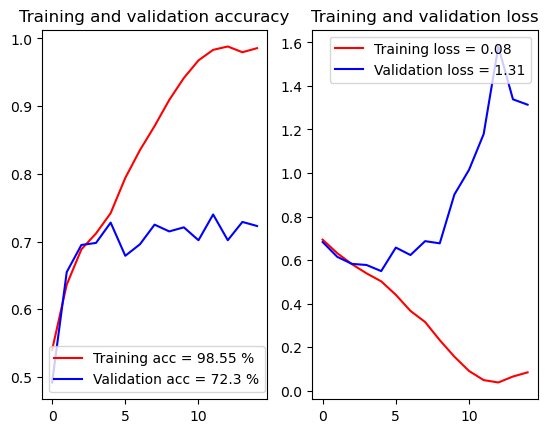

In [15]:
plot_acc_loss(history.history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
chaba01.jpg is a cat


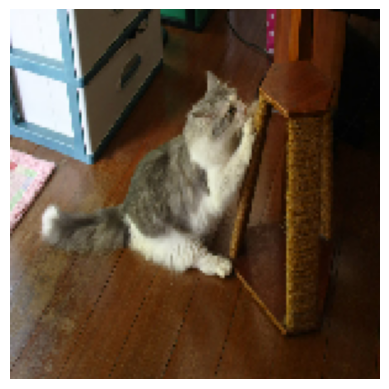

In [22]:
from keras.preprocessing import image
fn = "chaba01.jpg"
# predicting images
path='content/' + fn
img=image.load_img(path, target_size=(150, 150))
plt.imshow(img)
plt.axis('off')
x=image.img_to_array(img)
x=np.expand_dims(x, axis=0)
images = np.vstack([x])
classes = model.predict(images, batch_size=10)
if classes[0]>0:
    print(fn + " is a dog")
else:
    print(fn + " is a cat")